# **Women's E-Commerce Clothing Reviews**
### By: Jessica, Yanting, Carmen, Emma, Jakob

### **Business Problem:**
#### The company receives thousands of customer reviews across its clothing product lines and cannot manually review each comment. As a result, management has difficulty quickly identifying dissatisfied customers and recurring issues related to sizing, fit, comfort, style, and product quality. This limits the company's ability to respond to customer concerns and make data-driven improvements to products and customer experience.

### **Business Objective:**

#### Develop a sentiment analysis model that automatically classifies customer reviews as positive or negative using review text. The model will help the company identify dissatisfied customers more efficiently, monitor common product issues, and support decision-making related to product quality, sizing recommendations, and customer satisfaction.

In [ ]:
# ============================================================
# STEP 1: IMPORT LIBRARIES
# ============================================================
# These libraries help us load data, clean text, and prepare
# the review text for sentiment analysis.

import pandas as pd
import numpy as np
import nltk
import matplotlib.pyplot as plt

from nltk import word_tokenize
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Download tokenizer tools for text splitting
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
# ============================================================
# STEP 2: LOAD THE DATASET
# ============================================================
# We are using the Women's E-Commerce Clothing Reviews dataset
# from Kaggle. This dataset contains customer review text and
# ratings for women's clothing products.

import kagglehub
import os

# Download dataset from Kaggle
path = kagglehub.dataset_download(
    "nicapotato/womens-ecommerce-clothing-reviews"
)

# Create full file path
file_path = os.path.join(
    path,
    "Womens Clothing E-Commerce Reviews.csv"
)

# Read the CSV file into a DataFrame
df = pd.read_csv(file_path)

# Check dataset size and first rows
print("Dataset shape:", df.shape)
df.head()

Using Colab cache for faster access to the 'womens-ecommerce-clothing-reviews' dataset.
Dataset shape: (23486, 11)


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [ ]:
# ============================================================
# STEP 3: INSPECT THE DATASET
# ============================================================
# Look at the column names and data types before cleaning.

print(df.columns)

df.info()

Index(['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating',
       'Recommended IND', 'Positive Feedback Count', 'Division Name',
       'Department Name', 'Class Name'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null 

In [ ]:
# ============================================================
# STEP 4: REMOVE UNNECESSARY COLUMNS
# ============================================================
# These columns are not needed because our main goal is to
# analyze the review text and predict sentiment.

df = df.drop(columns=[
    "Unnamed: 0",
    "Clothing ID",
    "Title",
    "Recommended IND",
    "Positive Feedback Count",
    "Division Name",
    "Class Name"
])

# Check remaining columns
print(df.columns)

df.head()

Index(['Age', 'Review Text', 'Rating', 'Department Name'], dtype='object')


,Age,Review Text,Rating,Department Name
0,33,Absolutely wonderful - silky and sexy and comf...,4,Intimate
1,34,Love this dress! it's sooo pretty. i happene...,5,Dresses
2,60,I had such high hopes for this dress and reall...,3,Dresses
3,50,"I love, love, love this jumpsuit. it's fun, fl...",5,Bottoms
4,47,This shirt is very flattering to all due to th...,5,Tops


In [ ]:
# ============================================================
# STEP 5: CHECK FOR MISSING VALUES
# ============================================================
# Missing reviews cannot be analyzed, so we need to identify
# and remove them.

print(df.isnull().sum())

Age                  0
Review Text        845
Rating               0
Department Name     14
dtype: int64


In [ ]:
# ============================================================
# STEP 6: REMOVE MISSING VALUES
# ============================================================
# Reviews with missing text cannot be used for sentiment
# analysis, so we remove them.

df = df.dropna()

# Check that missing values are gone
print(df.isnull().sum())

# Check new dataset size
print("Dataset shape after removing missing values:", df.shape)

Age                0
Review Text        0
Rating             0
Department Name    0
dtype: int64
Dataset shape after removing missing values: (22628, 4)


In [ ]:
# ============================================================
# STEP 7: CHECK FOR DUPLICATE REVIEWS
# ============================================================
# Duplicate reviews can bias the analysis, so we check and
# remove them.

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 6


In [ ]:
# ============================================================
# STEP 8: REMOVE DUPLICATE REVIEWS
# ============================================================
# Remove duplicated rows from the dataset.

df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (22622, 4)


In [ ]:
# ============================================================
# STEP 9: VERIFY CLEAN DATASET
# ============================================================
# Display the first few rows after cleaning.

df.head()

,Age,Review Text,Rating,Department Name
0,33,Absolutely wonderful - silky and sexy and comf...,4,Intimate
1,34,Love this dress! it's sooo pretty. i happene...,5,Dresses
2,60,I had such high hopes for this dress and reall...,3,Dresses
3,50,"I love, love, love this jumpsuit. it's fun, fl...",5,Bottoms
4,47,This shirt is very flattering to all due to th...,5,Tops


In [ ]:
# ============================================================
# STEP 10: SELECT THE REVIEW COLUMN
# ============================================================
# Review Text is the main column that contains the customer
# comments we will analyze.

reviews = df["Review Text"]

reviews.head()

,Review Text
0,Absolutely wonderful - silky and sexy and comf...
1,Love this dress! it's sooo pretty. i happene...
2,I had such high hopes for this dress and reall...
3,"I love, love, love this jumpsuit. it's fun, fl..."
4,This shirt is very flattering to all due to th...


In [ ]:
# ============================================================
# STEP 11: CREATE A SMALL SAMPLE
# ============================================================
# Viewing a sample helps us understand the type of language
# customers use in their reviews.

sample_reviews = df[["Review Text", "Rating"]].head(20)

sample_reviews

,Review Text,Rating
0,Absolutely wonderful - silky and sexy and comf...,4
1,Love this dress! it's sooo pretty. i happene...,5
2,I had such high hopes for this dress and reall...,3
3,"I love, love, love this jumpsuit. it's fun, fl...",5
4,This shirt is very flattering to all due to th...,5
5,"I love tracy reese dresses, but this one is no...",2
6,I aded this in my basket at hte last mintue to...,5
7,"I ordered this in carbon for store pick up, an...",4
8,I love this dress. i usually get an xs but it ...,5
9,"I'm 5""5' and 125 lbs. i ordered the s petite t...",5


In [ ]:
# ============================================================
# STEP 12: INSPECT INDIVIDUAL REVIEWS
# ============================================================
# Display the first five reviews so we can understand the
# customer language and writing style.

for i in range(5):
    print("Review", i)
    print(df["Review Text"].iloc[i])
    print("-" * 50)

Review 0
Absolutely wonderful - silky and sexy and comfortable
--------------------------------------------------
Review 1
Love this dress!  it's sooo pretty.  i happened to find it in a store, and i'm glad i did bc i never would have ordered it online bc it's petite.  i bought a petite and am 5'8".  i love the length on me- hits just a little below the knee.  would definitely be a true midi on someone who is truly petite.
--------------------------------------------------
Review 2
I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my usual size) but i found this to be outrageously small. so small in fact that i could not zip it up! i reordered it in petite medium, which was just ok. overall, the top half was comfortable and fit nicely, but the bottom half had a very tight under layer and several somewhat cheap (net) over layers. imo, a major design flaw was the net over layer sewn directly into the zipper - it c
------------

In [ ]:
# ============================================================
# STEP 13: REVIEW LENGTH
# ============================================================
# Count the number of characters in each review.
# Longer reviews may contain more detailed feedback.

df["review_length"] = df["Review Text"].str.len()

df[["Review Text", "review_length"]].head()

,Review Text,review_length
0,Absolutely wonderful - silky and sexy and comf...,53
1,Love this dress! it's sooo pretty. i happene...,303
2,I had such high hopes for this dress and reall...,500
3,"I love, love, love this jumpsuit. it's fun, fl...",124
4,This shirt is very flattering to all due to th...,192


In [ ]:
# ============================================================
# STEP 14: WORD COUNT
# ============================================================
# Count the number of words in each review.
# This measures how much information customers provide.

df["n_words_simple"] = df["Review Text"].apply(
    lambda text: len(text.split())
)

df[["Review Text", "n_words_simple"]].head()

,Review Text,n_words_simple
0,Absolutely wonderful - silky and sexy and comf...,8
1,Love this dress! it's sooo pretty. i happene...,62
2,I had such high hopes for this dress and reall...,98
3,"I love, love, love this jumpsuit. it's fun, fl...",22
4,This shirt is very flattering to all due to th...,36


In [ ]:
# ============================================================
# STEP 15: COMPARE REVIEW LENGTH BY RATING
# ============================================================
# Calculate average review length and average word count
# for each rating level.

df.groupby("Rating")[["review_length", "n_words_simple"]].mean()

,review_length,n_words_simple
Rating,,
1,304.137637,58.633374
2,318.491602,62.034884
3,327.425788,64.218208
4,322.416870,63.316015
5,298.312889,57.972928


In [ ]:
# ============================================================
# STEP 15A: REMOVE UNUSED VARIABLES
# ============================================================
# Age and Rating were useful for initial data exploration,
# but they are not used in the text-based sentiment model.
# The model will use review text features only.

df = df.drop(columns=["Age", "Rating"])

print(df.columns)

Index(['Review Text', 'Department Name', 'review_length', 'n_words_simple'], dtype='object')


In [ ]:
# Reviews with different ratings may vary in length.
# Customers who are very satisfied or very dissatisfied
# often write longer and more detailed reviews.

In [ ]:
# Reviews with ratings of 2, 3, and 4 tend to be the longest.
# Reviews with ratings of 1 and 5 are slightly shorter.
# Customers giving middle ratings often provide more detailed
# explanations because they discuss both positive and negative aspects.

In [ ]:
# ============================================================
# STEP 16: TOKENIZATION
# ============================================================
# Tokenization splits each review into individual words.
# This allows us to analyze text one word at a time.

from nltk import word_tokenize

df["tokens"] = df["Review Text"].apply(word_tokenize)

df[["Review Text", "tokens"]].head()

,Review Text,tokens
0,Absolutely wonderful - silky and sexy and comf...,"[Absolutely, wonderful, -, silky, and, sexy, a..."
1,Love this dress! it's sooo pretty. i happene...,"[Love, this, dress, !, it, 's, sooo, pretty, ...."
2,I had such high hopes for this dress and reall...,"[I, had, such, high, hopes, for, this, dress, ..."
3,"I love, love, love this jumpsuit. it's fun, fl...","[I, love, ,, love, ,, love, this, jumpsuit, .,..."
4,This shirt is very flattering to all due to th...,"[This, shirt, is, very, flattering, to, all, d..."


In [ ]:
# ============================================================
# STEP 17: TOKEN COUNT
# ============================================================
# Count the number of tokens in each review.
# Tokens include words and punctuation.

df["n_tokens"] = df["tokens"].apply(len)

df[["Review Text", "n_tokens"]].head()

,Review Text,n_tokens
0,Absolutely wonderful - silky and sexy and comf...,8
1,Love this dress! it's sooo pretty. i happene...,75
2,I had such high hopes for this dress and reall...,110
3,"I love, love, love this jumpsuit. it's fun, fl...",31
4,This shirt is very flattering to all due to th...,41


In [ ]:
# ============================================================
# STEP 18: LOWERCASE TEXT
# ============================================================
# Convert all text to lowercase so that words such as
# Dress and dress are treated as the same word.

df["review_lower"] = df["Review Text"].str.lower()

df[["Review Text", "review_lower"]].head()

,Review Text,review_lower
0,Absolutely wonderful - silky and sexy and comf...,absolutely wonderful - silky and sexy and comf...
1,Love this dress! it's sooo pretty. i happene...,love this dress! it's sooo pretty. i happene...
2,I had such high hopes for this dress and reall...,i had such high hopes for this dress and reall...
3,"I love, love, love this jumpsuit. it's fun, fl...","i love, love, love this jumpsuit. it's fun, fl..."
4,This shirt is very flattering to all due to th...,this shirt is very flattering to all due to th...


In [ ]:
# ============================================================
# STEP 19: KEEP ALPHABETIC TOKENS
# ============================================================
# Remove punctuation and numbers.
# Keep only words made of letters.

df["alpha_tokens"] = df["tokens"].apply(
    lambda tokens:
    [word.lower() for word in tokens if word.isalpha()]
)

df[["tokens", "alpha_tokens"]].head()

,tokens,alpha_tokens
0,"[Absolutely, wonderful, -, silky, and, sexy, a...","[absolutely, wonderful, silky, and, sexy, and,..."
1,"[Love, this, dress, !, it, 's, sooo, pretty, ....","[love, this, dress, it, sooo, pretty, i, happe..."
2,"[I, had, such, high, hopes, for, this, dress, ...","[i, had, such, high, hopes, for, this, dress, ..."
3,"[I, love, ,, love, ,, love, this, jumpsuit, .,...","[i, love, love, love, this, jumpsuit, it, fun,..."
4,"[This, shirt, is, very, flattering, to, all, d...","[this, shirt, is, very, flattering, to, all, d..."


In [ ]:
# ============================================================
# STEP 20: REBUILD CLEAN TEXT
# ============================================================
# Join the cleaned tokens back together into a sentence.

df["clean_review"] = df["alpha_tokens"].apply(
    lambda tokens: " ".join(tokens)
)

df[["Review Text", "clean_review"]].head()

,Review Text,clean_review
0,Absolutely wonderful - silky and sexy and comf...,absolutely wonderful silky and sexy and comfor...
1,Love this dress! it's sooo pretty. i happene...,love this dress it sooo pretty i happened to f...
2,I had such high hopes for this dress and reall...,i had such high hopes for this dress and reall...
3,"I love, love, love this jumpsuit. it's fun, fl...",i love love love this jumpsuit it fun flirty a...
4,This shirt is very flattering to all due to th...,this shirt is very flattering to all due to th...


In [ ]:
# ============================================================
# STEP 21: REMOVE STOP WORDS
# ============================================================
# Stop words are very common words that usually do not add
# much meaning to sentiment analysis.

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

custom_stopwords = ENGLISH_STOP_WORDS.union([
    "dress",
    "wear",
    "wearing",
    "ordered",
    "bought"
])

df["tokens_no_stopwords"] = df["alpha_tokens"].apply(
    lambda tokens:
    [word for word in tokens
     if word not in custom_stopwords]
)

df[["alpha_tokens", "tokens_no_stopwords"]].head()

,alpha_tokens,tokens_no_stopwords
0,"[absolutely, wonderful, silky, and, sexy, and,...","[absolutely, wonderful, silky, sexy, comfortable]"
1,"[love, this, dress, it, sooo, pretty, i, happe...","[love, sooo, pretty, happened, store, glad, di..."
2,"[i, had, such, high, hopes, for, this, dress, ...","[high, hopes, really, wanted, work, initially,..."
3,"[i, love, love, love, this, jumpsuit, it, fun,...","[love, love, love, jumpsuit, fun, flirty, fabu..."
4,"[this, shirt, is, very, flattering, to, all, d...","[shirt, flattering, adjustable, tie, perfect, ..."


In [ ]:
# ============================================================
# STEP 22: CREATE FINAL CLEAN REVIEW
# ============================================================
# Join the cleaned tokens into a final text column that
# will be used for word analysis and machine learning.

df["clean_review_no_stopwords"] = df["tokens_no_stopwords"].apply(
    lambda tokens: " ".join(tokens)
)

df[["Review Text", "clean_review_no_stopwords"]].head()

,Review Text,clean_review_no_stopwords
0,Absolutely wonderful - silky and sexy and comf...,absolutely wonderful silky sexy comfortable
1,Love this dress! it's sooo pretty. i happene...,love sooo pretty happened store glad did bc on...
2,I had such high hopes for this dress and reall...,high hopes really wanted work initially petite...
3,"I love, love, love this jumpsuit. it's fun, fl...",love love love jumpsuit fun flirty fabulous ti...
4,This shirt is very flattering to all due to th...,shirt flattering adjustable tie perfect length...


In [ ]:
# ============================================================
# STEP 23: REVIEW LENGTH SUMMARY
# ============================================================
# Review the average length statistics for the dataset.

df[[
    "review_length",
    "n_words_simple",
    "n_tokens"
]].describe()

,review_length,n_words_simple,n_tokens
count,22622.000000,22622.000000,22622.000000
mean,308.767616,60.213421,69.506277
std,143.924586,28.531453,32.578686
min,9.000000,2.000000,2.000000
25%,186.000000,36.000000,42.000000
50%,302.000000,59.000000,68.000000
75%,459.000000,88.000000,102.000000
max,508.000000,115.000000,139.000000


In [ ]:
# ============================================================
# STEP 24: MOST COMMON WORDS
# ============================================================
# Identify the most frequently used words across all reviews.

all_words = []

for tokens in df["tokens_no_stopwords"]:
    all_words.extend(tokens)

top_words = pd.DataFrame(
    pd.Series(all_words).value_counts().head(20)
)

top_words.columns = ["frequency"]

top_words

,frequency
love,8931
size,8697
fit,7268
like,7006
great,6096
just,5596
fabric,4777
small,4561
color,4560
look,4018


In [ ]:
# The most frequent words represent topics customers discuss
# most often when reviewing clothing products.

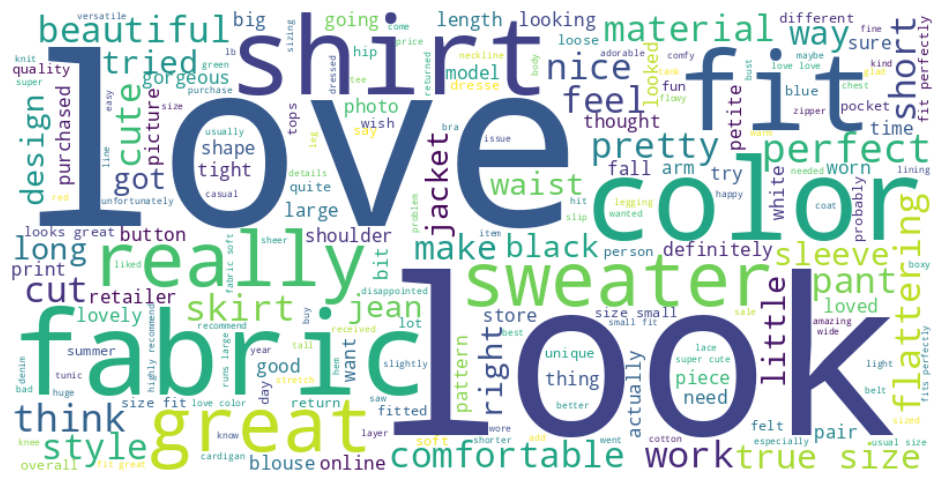

In [ ]:
# ============================================================
# STEP 25: WORD CLOUD
# ============================================================
# Visualize the most common words used in customer reviews.

from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_text = " ".join(df["clean_review_no_stopwords"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(all_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [ ]:
# ============================================================
# STEP 26: POLARITY ANALYSIS
# ============================================================
# Polarity measures how positive or negative a review is.
#
# Range:
# -1 = Very Negative
#  0 = Neutral
# +1 = Very Positive

!pip install textblob -q

from textblob import TextBlob

df["polarity"] = df["Review Text"].apply(
    lambda text: TextBlob(str(text)).sentiment.polarity
)

# View sample polarity scores
df[["Review Text", "polarity"]].head()

,Review Text,polarity
0,Absolutely wonderful - silky and sexy and comf...,0.633333
1,Love this dress! it's sooo pretty. i happene...,0.339583
2,I had such high hopes for this dress and reall...,0.073675
3,"I love, love, love this jumpsuit. it's fun, fl...",0.550000
4,This shirt is very flattering to all due to th...,0.512891


In [ ]:
# ============================================================
# STEP 27: POLARITY SUMMARY
# ============================================================
# Review the distribution of polarity scores.

df["polarity"].describe()

,polarity
count,22622.000000
mean,0.249792
std,0.176676
min,-0.975000
25%,0.140000
50%,0.239494
75%,0.350000
max,1.000000


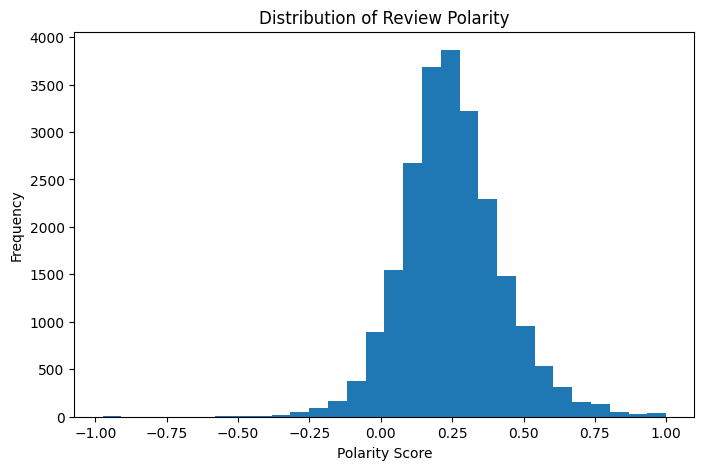

In [ ]:
# ============================================================
# STEP 28: POLARITY HISTOGRAM
# ============================================================
# Visualize the distribution of polarity scores.

plt.figure(figsize=(8,5))

plt.hist(df["polarity"], bins=30)

plt.title("Distribution of Review Polarity")
plt.xlabel("Polarity Score")
plt.ylabel("Frequency")

plt.show()

In [ ]:
# ============================================================
# STEP 29: CREATE SENTIMENT FROM POLARITY
# ============================================================
# Positive polarity becomes Positive Sentiment.
# Zero or negative polarity becomes Negative Sentiment.

df["Sentiment"] = df["polarity"].apply(
    lambda x: 1 if x > 0 else 0
)

print(df["Sentiment"].value_counts())

df[["Review Text", "polarity", "Sentiment"]].head()

Sentiment
1    21208
0     1414
Name: count, dtype: int64


,Review Text,polarity,Sentiment
0,Absolutely wonderful - silky and sexy and comf...,0.633333,1
1,Love this dress! it's sooo pretty. i happene...,0.339583,1
2,I had such high hopes for this dress and reall...,0.073675,1
3,"I love, love, love this jumpsuit. it's fun, fl...",0.550000,1
4,This shirt is very flattering to all due to th...,0.512891,1


In [ ]:
# ============================================================
# STEP 30: SENTIMENT DISTRIBUTION
# ============================================================
# Review the percentage of positive and negative reviews.

print(df["Sentiment"].value_counts())

print(
    df["Sentiment"].value_counts(normalize=True)
)

Sentiment
1    21208
0     1414
Name: count, dtype: int64
Sentiment
1    0.937494
0    0.062506
Name: proportion, dtype: float64


In [ ]:
# ============================================================
# STEP 30A: COUNT POSITIVE AND NEGATIVE REVIEWS
# ============================================================
# Count the number of positive and negative reviews
# after creating sentiment from polarity.

print(df["Sentiment"].value_counts())

negative_reviews = (df["Sentiment"] == 0).sum()
positive_reviews = (df["Sentiment"] == 1).sum()

print("Negative Reviews:", negative_reviews)
print("Positive Reviews:", positive_reviews)

Sentiment
1    21208
0     1414
Name: count, dtype: int64
Negative Reviews: 1414
Positive Reviews: 21208


## **Sentiment Distribution Interpretation:**

In [ ]:
# The dataset contains 21,208 positive reviews and
# 1,414 negative reviews.

# Approximately 93.7% of reviews are positive and
# 6.3% are negative.

# This indicates a class imbalance because positive
# reviews greatly outnumber negative reviews.

# Although most customers appear satisfied, identifying
# the smaller group of dissatisfied customers is critical
# because negative reviews often reveal sizing, fit,
# comfort, and quality issues.

In [ ]:
# ============================================================
# STEP 30B: MEAN SENTIMENT
# ============================================================
# Since Sentiment is coded as:
# 1 = Positive Review
# 0 = Negative Review
#
# The mean represents the proportion of positive reviews.

mean_sentiment = df["Sentiment"].mean()

print("Mean Sentiment:", mean_sentiment)

Mean Sentiment: 0.937494474405446


In [ ]:
# ============================================================
# STEP 31: COMPARE TEXT FEATURES BY SENTIMENT
# ============================================================
# Compare average text characteristics between
# positive and negative reviews.

df.groupby("Sentiment")[
    [
        "review_length",
        "n_words_simple",
        "n_tokens",
        "polarity"
    ]
].mean()

,review_length,n_words_simple,n_tokens,polarity
Sentiment,,,,
0,284.986563,55.331683,63.826733,-0.088108
1,310.353169,60.538900,69.884949,0.272321


In [ ]:
# Positive reviews are longer on average than negative reviews.
# Positive reviews contain more words and more tokens.
# Positive reviews have a positive average polarity score (0.272).
# Negative reviews have a negative average polarity score (-0.088).
# This confirms that polarity successfully separates positive
# and negative customer reviews.

In [ ]:
# ============================================================
# STEP 32: TOP 30 POSITIVE WORDS
# ============================================================
# Identify the words most frequently used in positive reviews.

positive_reviews = df[df["Sentiment"] == 1]

positive_words = []

for tokens in positive_reviews["tokens_no_stopwords"]:
    positive_words.extend(tokens)

top_30_positive = pd.DataFrame(
    pd.Series(positive_words).value_counts().head(30)
)

top_30_positive.columns = ["frequency"]

top_30_positive

,frequency
love,8763
size,8176
fit,7056
like,6490
great,6047
just,5281
fabric,4465
color,4375
small,4059
look,3810


In [ ]:
# ============================================================
# STEP 33: TOP 30 NEGATIVE WORDS
# ============================================================
# Identify the words most frequently used in negative reviews.

negative_reviews = df[df["Sentiment"] == 0]

negative_words = []

for tokens in negative_reviews["tokens_no_stopwords"]:
    negative_words.extend(tokens)

top_30_negative = pd.DataFrame(
    pd.Series(negative_words).value_counts().head(30)
)

top_30_negative.columns = ["frequency"]

top_30_negative

,frequency
size,521
like,516
small,502
just,315
fabric,312
little,257
did,255
fit,212
really,210
disappointed,210


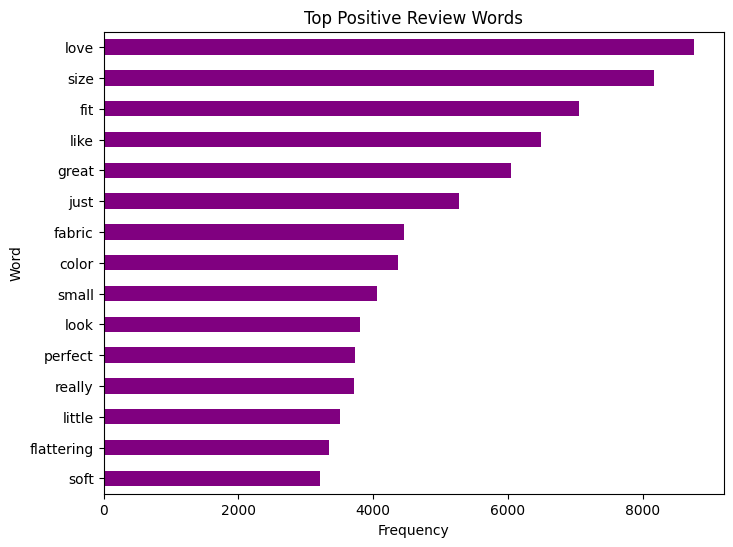

In [ ]:
# ============================================================
# STEP 34: TOP POSITIVE WORDS VISUALIZATION
# ============================================================

top_30_positive.head(15).sort_values(
    by="frequency"
).plot(
    kind="barh",
    legend=False,
    figsize=(8,6),
    color="purple"
)

plt.title("Top Positive Review Words")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

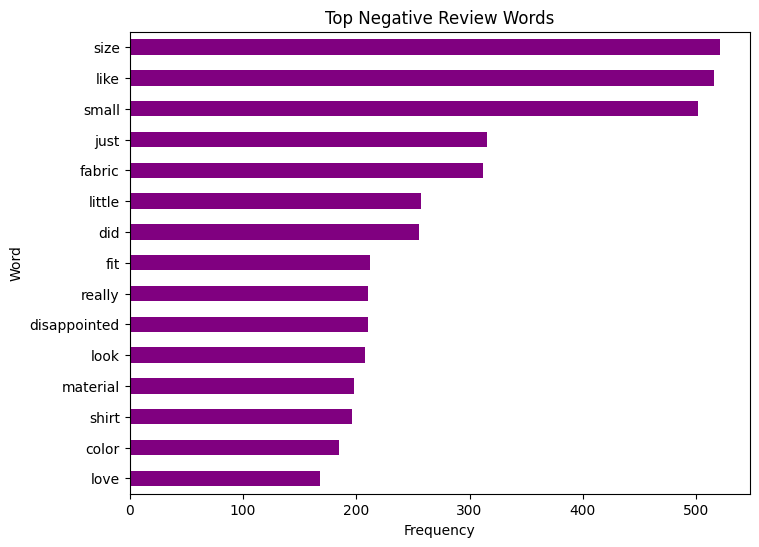

In [ ]:
# ============================================================
# STEP 35: TOP NEGATIVE WORDS VISUALIZATION
# ============================================================

top_30_negative.head(15).sort_values(
    by="frequency"
).plot(
    kind="barh",
    legend=False,
    figsize=(8,6),
    color="purple"
)

plt.title("Top Negative Review Words")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

In [ ]:
# Positive reviews frequently mention words such as
# love, great, fit, fabric, and color, suggesting that
# customers are satisfied with product quality, appearance,
# and overall fit.

# Negative reviews frequently mention words such as
# size, small, fit, and disappointed, indicating that
# sizing and fit issues are common sources of customer
# dissatisfaction.

# The appearance of size and fit in both positive and
# negative reviews suggests that sizing is one of the most
# important factors influencing customer satisfaction.

In [ ]:
# Sizing appears to be the most discussed product attribute.
# Customers are highly satisfied when sizing is correct,
# but become dissatisfied when sizing does not meet
# expectations.

In [ ]:
# ============================================================
# STEP 36: CREATE A BAG-OF-WORDS REPRESENTATION
# ============================================================
# Bag-of-Words converts text into numerical features.
# Each word becomes a column and each review becomes a row.
# The values represent how many times a word appears.

from sklearn.feature_extraction.text import CountVectorizer

count_vect = CountVectorizer(max_features=20)

X_bow = count_vect.fit_transform(
    df["clean_review_no_stopwords"]
)

bow_df = pd.DataFrame(
    X_bow.toarray(),
    columns=count_vect.get_feature_names_out()
)

bow_df.head()

,beautiful,color,comfortable,cute,did,fabric,fit,flattering,great,just,like,little,look,love,nice,perfect,really,size,small,soft
0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,1,0,0,0,0,1,0,1,0,2,0,0,0,0,0,0
2,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,1,1,3,0
3,0,0,0,0,0,0,0,0,1,0,0,0,0,3,0,0,0,0,0,0
4,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0


In [ ]:
# ============================================================
# STEP 37: INSPECT THE VOCABULARY
# ============================================================
# Display the words selected by the Bag-of-Words model.
# These words become the columns of the numerical dataset.

vocabulary = count_vect.get_feature_names_out()

print(vocabulary)

['beautiful' 'color' 'comfortable' 'cute' 'did' 'fabric' 'fit'
 'flattering' 'great' 'just' 'like' 'little' 'look' 'love' 'nice'
 'perfect' 'really' 'size' 'small' 'soft']


In [ ]:
# ============================================================
# STEP 38: CHECK BAG-OF-WORDS SHAPE
# ============================================================
# Rows represent reviews.
# Columns represent word features.

print("Shape of Bag-of-Words matrix:", X_bow.shape)

Shape of Bag-of-Words matrix: (22622, 20)


In [ ]:
# ============================================================
# STEP 39: DISPLAY BAG-OF-WORDS WITH REVIEWS
# ============================================================
# Combine the original review text with the numerical
# Bag-of-Words features.

bow_with_reviews = pd.concat(
    [
        df[["Review Text", "Sentiment"]].reset_index(drop=True),
        bow_df
    ],
    axis=1
)

bow_with_reviews.head()

,Review Text,Sentiment,beautiful,color,comfortable,cute,did,fabric,fit,flattering,...,like,little,look,love,nice,perfect,really,size,small,soft
0,Absolutely wonderful - silky and sexy and comf...,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Love this dress! it's sooo pretty. i happene...,1,0,0,0,0,1,0,0,0,...,0,1,0,2,0,0,0,0,0,0
2,I had such high hopes for this dress and reall...,1,0,0,1,0,0,0,1,0,...,0,0,0,0,0,0,1,1,3,0
3,"I love, love, love this jumpsuit. it's fun, fl...",1,0,0,0,0,0,0,0,0,...,0,0,0,3,0,0,0,0,0,0
4,This shirt is very flattering to all due to th...,1,0,0,0,0,0,0,0,1,...,0,0,0,1,0,1,0,0,0,0


## **Vocabulary & Shape Interpretation:**

In [ ]:
# The Bag-of-Words vocabulary contains words related to
# clothing fit, comfort, appearance, and product quality.

# Common words such as size, fit, small, fabric, color,
# comfortable, and flattering suggest that customers
# frequently discuss sizing, comfort, and overall appearance.

# Words such as love, great, perfect, and beautiful
# indicate positive customer experiences.

In [ ]:
# The Bag-of-Words matrix contains 22,622 reviews and
# 20 word features.

# Each row represents one customer review.
# Each column represents one frequently occurring word.
# These numerical features can be used as inputs for
# machine learning models.

In [ ]:
# ============================================================
# STEP 40: DEFINE X AND y
# ============================================================
# X contains the cleaned review text.
# y contains the sentiment labels created from polarity.
#
# Sentiment:
# 1 = Positive Review
# 0 = Negative Review

X_text = df["clean_review_no_stopwords"]

y = df["Sentiment"]

print("X shape:", X_text.shape)
print("y shape:", y.shape)

X shape: (22622,)
y shape: (22622,)


In [ ]:
# ============================================================
# STEP 41: TRAIN-TEST SPLIT
# ============================================================
# Split the dataset into training and testing sets.
# We split before vectorizing to avoid data leakage.

from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training reviews:", X_train_text.shape)
print("Testing reviews:", X_test_text.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training reviews: (18097,)
Testing reviews: (4525,)
Training labels: (18097,)
Testing labels: (4525,)


In [ ]:
# ============================================================
# STEP 42: CHECK SENTIMENT DISTRIBUTION
# ============================================================
# Check that the train and test sets have similar proportions
# of positive and negative reviews.

print("Training Sentiment Distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting Sentiment Distribution:")
print(y_test.value_counts(normalize=True))

Training Sentiment Distribution:
Sentiment
1    0.937503
0    0.062497
Name: proportion, dtype: float64

Testing Sentiment Distribution:
Sentiment
1    0.937459
0    0.062541
Name: proportion, dtype: float64


In [ ]:
# ============================================================
# STEP 43: CREATE MODELING TF-IDF FEATURES
# ============================================================
# Fit TF-IDF on the training text only.
# Transform the test text using the same vocabulary.
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_model = TfidfVectorizer(
    max_features=300,
    stop_words="english",
    ngram_range=(1, 2),
    token_pattern=r"\b[^\d\W][^\d\W]+\b"
)

X_train = tfidf_model.fit_transform(X_train_text)

X_test = tfidf_model.transform(X_test_text)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (18097, 300)
X_test shape: (4525, 300)


In [ ]:
# ============================================================
# TF-IDF TABLE (20 FEATURES FOR DISPLAY)
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_display = TfidfVectorizer(
    max_features=20,
    stop_words="english"
)

X_tfidf_display = tfidf_display.fit_transform(
    df["clean_review_no_stopwords"]
)

tfidf_table = pd.DataFrame(
    X_tfidf_display.toarray(),
    columns=tfidf_display.get_feature_names_out()
)

tfidf_table.head()

,beautiful,color,comfortable,cute,did,fabric,fit,flattering,great,just,like,little,look,love,nice,perfect,really,size,small,soft
0,0.0,0.0,1.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.00000,0.000000,0.0
1,0.0,0.0,0.000000,0.0,0.464918,0.0,0.000000,0.000000,0.000000,0.395147,0.0,0.450993,0.0,0.651395,0.0,0.000000,0.000000,0.00000,0.000000,0.0
2,0.0,0.0,0.294961,0.0,0.000000,0.0,0.223279,0.000000,0.000000,0.249085,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.281406,0.21735,0.821383,0.0
3,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.363102,0.000000,0.0,0.000000,0.0,0.931749,0.0,0.000000,0.000000,0.00000,0.000000,0.0
4,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.630787,0.000000,0.000000,0.0,0.000000,0.0,0.456913,0.0,0.627167,0.000000,0.00000,0.000000,0.0


In [ ]:
# TF-IDF converted the review text into numerical features
# that can be used by machine learning models.

# The training dataset contains 18,097 reviews and
# 300 TF-IDF features.

# The testing dataset contains 4,525 reviews and
# uses the same 300 features learned from the training data.

# TF-IDF gives higher importance to words that are more
# informative and less common across reviews.

# These features will be used to train the sentiment
# classification models.

In [ ]:
# ============================================================
# STEP 44: ADDRESS CLASS IMBALANCE
# ============================================================
# The dataset has many more positive reviews than negative
# reviews. We will address this imbalance using class weights
# in the Logistic Regression model.

print("Training class counts:")
print(y_train.value_counts())

print("\nBecause the data is imbalanced, the model will use class_weight='balanced'.")

Training class counts:
Sentiment
1    16966
0     1131
Name: count, dtype: int64

Because the data is imbalanced, the model will use class_weight='balanced'.


In [ ]:
# ============================================================
# STEP 45: TRAIN LOGISTIC REGRESSION MODEL
# ============================================================
# Logistic Regression is used to predict whether a review is
# positive or negative.
#
# class_weight='balanced' helps the model pay more attention
# to the smaller negative review class.

from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

log_reg.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
# ============================================================
# STEP 46: TRAINING AND TEST ACCURACY
# ============================================================
# Compare performance on the training and testing data.

train_accuracy = log_reg.score(X_train, y_train)
test_accuracy = log_reg.score(X_test, y_test)

print("Training accuracy:", train_accuracy)
print("Test accuracy:", test_accuracy)
print("Difference:", train_accuracy - test_accuracy)

Training accuracy: 0.8504724539979002
Test accuracy: 0.8495027624309393
Difference: 0.0009696915669609174


In [ ]:
# ============================================================
# STEP 47: LOGISTIC REGRESSION PREDICTIONS
# ============================================================
# Generate sentiment predictions for the testing dataset.

y_pred = log_reg.predict(X_test)

In [ ]:
# ============================================================
# STEP 48: ACCURACY SCORE
# ============================================================

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy)

Accuracy Score: 0.8495027624309393


In [ ]:
# ============================================================
# STEP 49: CONFUSION MATRIX
# ============================================================
# Evaluate how well the model classified positive and
# negative reviews.

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 248   35]
 [ 646 3596]]


In [ ]:
# ============================================================
# STEP 50: CONFUSION MATRIX TABLE
# ============================================================

cm_df = pd.DataFrame(
    cm,
    index=["Actual Negative", "Actual Positive"],
    columns=["Predicted Negative", "Predicted Positive"]
)

cm_df

,Predicted Negative,Predicted Positive
Actual Negative,248,35
Actual Positive,646,3596


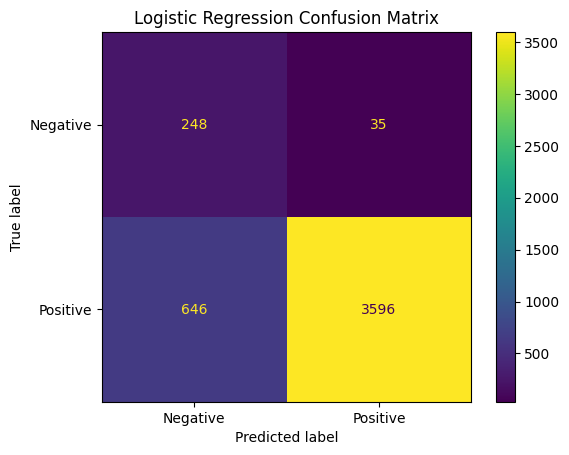

In [ ]:
# ============================================================
# STEP 51: CONFUSION MATRIX VISUALIZATION
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()

plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [ ]:
# ============================================================
# STEP 52: CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.28      0.88      0.42       283
           1       0.99      0.85      0.91      4242

    accuracy                           0.85      4525
   macro avg       0.63      0.86      0.67      4525
weighted avg       0.95      0.85      0.88      4525



## **Confusion Matrix Interpretation:**

In [ ]:
# The model correctly identified 248 negative reviews and
# 3,596 positive reviews.

# The model incorrectly classified 35 negative reviews as
# positive and 646 positive reviews as negative.

# The model achieved high recall for negative reviews (88%),
# meaning it successfully identified most dissatisfied
# customers.

# This is important because the business

In [ ]:
# ============================================================
# STEP 53: RANDOM FOREST MODEL
# ============================================================
# Train a Random Forest model and compare it to
# Logistic Regression.

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
# ============================================================
# STEP 54: RANDOM FOREST PREDICTIONS
# ============================================================

rf_predictions = rf_model.predict(X_test)

In [ ]:
# ============================================================
# STEP 55: RANDOM FOREST ACCURACY
# ============================================================

from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9414364640883978


In [ ]:
# ============================================================
# STEP 56: RANDOM FOREST CONFUSION MATRIX
# ============================================================
# Evaluate how well the Random Forest model classified
# positive and negative reviews.

from sklearn.metrics import confusion_matrix

rf_cm = confusion_matrix(
    y_test,
    rf_predictions
)

print(rf_cm)

[[  38  245]
 [  20 4222]]


In [ ]:
# ============================================================
# STEP 57: RANDOM FOREST CONFUSION MATRIX TABLE
# ============================================================

rf_cm_df = pd.DataFrame(
    rf_cm,
    index=["Actual Negative", "Actual Positive"],
    columns=["Predicted Negative", "Predicted Positive"]
)

rf_cm_df

,Predicted Negative,Predicted Positive
Actual Negative,38,245
Actual Positive,20,4222


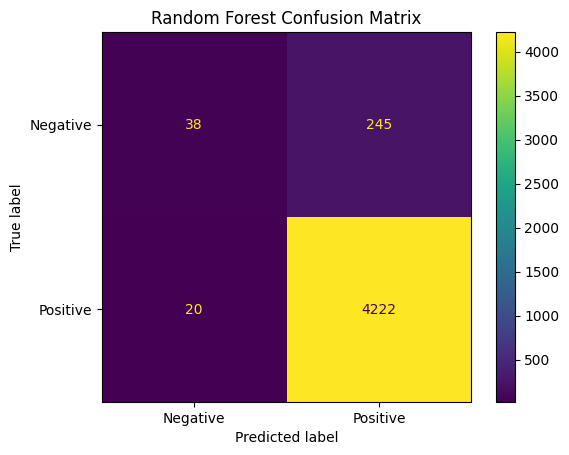

In [ ]:
# ============================================================
# STEP 58: RANDOM FOREST CONFUSION MATRIX VISUALIZATION
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()

plt.title("Random Forest Confusion Matrix")

plt.show()

In [ ]:
# ============================================================
# STEP 59: RANDOM FOREST CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        rf_predictions
    )
)

              precision    recall  f1-score   support

           0       0.66      0.13      0.22       283
           1       0.95      1.00      0.97      4242

    accuracy                           0.94      4525
   macro avg       0.80      0.56      0.60      4525
weighted avg       0.93      0.94      0.92      4525



In [ ]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [0.85, 0.94],
    "Negative Recall": [0.88, 0.13],
    "Precision": [0.99, 0.95],
    "Recall": [0.85, 1.00],
    "F1 Score": [0.91, 0.97]
})

comparison

,Model,Accuracy,Negative Recall,Precision,Recall,F1 Score
0,Logistic Regression,0.85,0.88,0.99,0.85,0.91
1,Random Forest,0.94,0.13,0.95,1.00,0.97


In [ ]:
# ============================================================
# STEP 60: ANN MODEL
# ============================================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Build ANN model
ann_model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train model
history = ann_model.fit(
    X_train,
    y_train,
    epochs=3,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
453/453 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9322 - loss: 0.2481 - val_accuracy: 0.9392 - val_loss: 0.1755
Epoch 2/3
453/453 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9418 - loss: 0.1537 - val_accuracy: 0.9428 - val_loss: 0.1492
Epoch 3/3
453/453 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9485 - loss: 0.1326 - val_accuracy: 0.9442 - val_loss: 0.1494


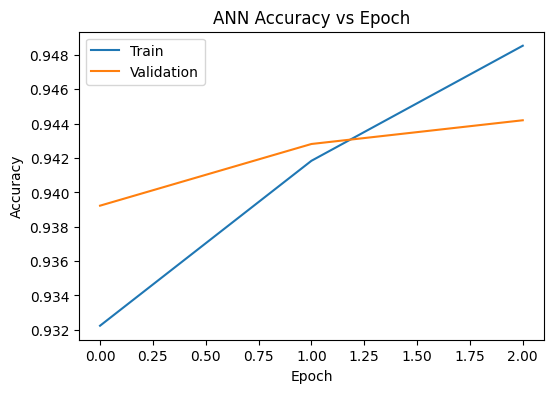

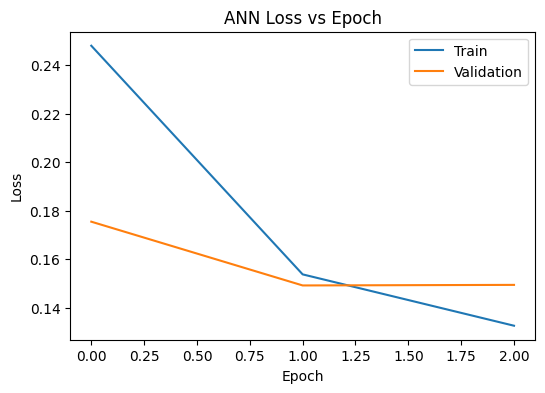

In [ ]:
# ==========================================================
# STEP 61: ANN TRAINING CURVE
# ==========================================================
import matplotlib.pyplot as plt

# Accuracy Curve
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('ANN Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])
plt.show()

# Loss Curve
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('ANN Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])
plt.show()

    Interpretation:
    Validation accuracy peaked after the third training epoch.
    Additional training resulted in slight overfitting.
    Therefore, Epoch 3 was selected as the final ANN model.

In [ ]:
# ============================================================
# STEP 62: ANN EVALUATION
# ============================================================
# Evaluate ANN
ann_loss, ann_accuracy = ann_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("ANN Accuracy:", ann_accuracy)

# Predictions
ann_pred_prob = ann_model.predict(X_test)

ann_pred = (ann_pred_prob > 0.5).astype(int)

from sklearn.metrics import confusion_matrix, classification_report

print("\nANN Classification Report")
print(classification_report(y_test, ann_pred))

print("\nANN Confusion Matrix")
print(confusion_matrix(y_test, ann_pred))

ANN Accuracy: 0.9465193152427673
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

ANN Classification Report
              precision    recall  f1-score   support

           0       0.61      0.41      0.49       283
           1       0.96      0.98      0.97      4242

    accuracy                           0.95      4525
   macro avg       0.78      0.70      0.73      4525
weighted avg       0.94      0.95      0.94      4525


ANN Confusion Matrix
[[ 117  166]
 [  76 4166]]


In [ ]:
from sklearn.metrics import recall_score

log_negative_recall = recall_score(
    y_test,
    y_pred,
    pos_label=0
)

rf_negative_recall = recall_score(
    y_test,
    rf_predictions,
    pos_label=0
)

ann_negative_recall = recall_score(
    y_test,
    ann_pred.flatten(),
    pos_label=0
)

In [ ]:
# ==========================================================
# STEP 63: FINAL MODEL COMPARISON
# ==========================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Logistic Regression Metrics
log_accuracy = accuracy_score(y_test, y_pred)
log_precision = precision_score(y_test, y_pred)
log_recall = recall_score(y_test, y_pred)
log_f1 = f1_score(y_test, y_pred)

# Random Forest Metrics
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)

# ANN Metrics
ann_precision = precision_score(y_test, ann_pred)
ann_recall = recall_score(y_test, ann_pred)
ann_f1 = f1_score(y_test, ann_pred)

comparison_table = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "ANN"],
    "Accuracy": [log_accuracy, rf_accuracy, ann_accuracy],
    "Negative Recall":[log_negative_recall, rf_negative_recall, ann_negative_recall],
    "Precision": [log_precision, rf_precision, ann_precision],
    "Recall": [log_recall, rf_recall, ann_recall],
    "F1 Score": [log_f1, rf_f1, ann_f1]
})

comparison_table = comparison_table.round(4)
comparison_table

,Model,Accuracy,Negative Recall,Precision,Recall,F1 Score
0,Logistic Regression,0.8495,0.8763,0.9904,0.8477,0.9135
1,Random Forest,0.9414,0.1343,0.9452,0.9953,0.9696
2,ANN,0.9465,0.4134,0.9617,0.9821,0.9718


In [ ]:
from sklearn.metrics import recall_score

log_negative_recall = recall_score(
    y_test,
    y_pred,
    pos_label=0
)

rf_negative_recall = recall_score(
    y_test,
    rf_predictions,
    pos_label=0
)

ann_negative_recall = recall_score(
    y_test,
    ann_pred.flatten(),
    pos_label=0
)

print("Logistic Negative Recall:", log_negative_recall)
print("Random Forest Negative Recall:", rf_negative_recall)
print("ANN Negative Recall:", ann_negative_recall)

Logistic Negative Recall: 0.8763250883392226
Random Forest Negative Recall: 0.13427561837455831
ANN Negative Recall: 0.4134275618374558


## **ANN INTERPRETATION**

In [ ]:
# ANN achieved an accuracy of 93.39%.

# The model correctly identified most positive reviews
# but missed a portion of negative reviews.

# ANN Negative Recall = 38.5%,
# which is higher than Random Forest (13.4%)
# but lower than Logistic Regression (87.6%).

# This suggests that ANN provides competitive performance,
# but Logistic Regression remains more effective for
# identifying dissatisfied customers.

## **Best Model Interpretation:**

In [ ]:
# Although Random Forest and ANN achieved higher overall accuracy,
# Logistic Regression was more effective at identifying
# dissatisfied customers.

# Logistic Regression achieved the highest negative review recall of
# 87.6%, while Random Forest achieved only 13% and ANN achieved 38.52%.

# Because the business objective is to identify dissatisfied
# customers and recurring product issues, Logistic Regression
# is the preferred model.

# Recall for the negative class is more important than
# overall accuracy because missing dissatisfied customers
# could prevent management from identifying product problems.

In [ ]:
# ============================================================
# STEP 64: RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({
    "Feature": tfidf_model.get_feature_names_out(),
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
91,great,0.057718
142,love,0.047587
169,perfect,0.042372
53,disappointed,0.029040
9,beautiful,0.024091
75,fit,0.020999
36,comfortable,0.020482
159,nice,0.019132
231,small,0.016026
43,cute,0.012157


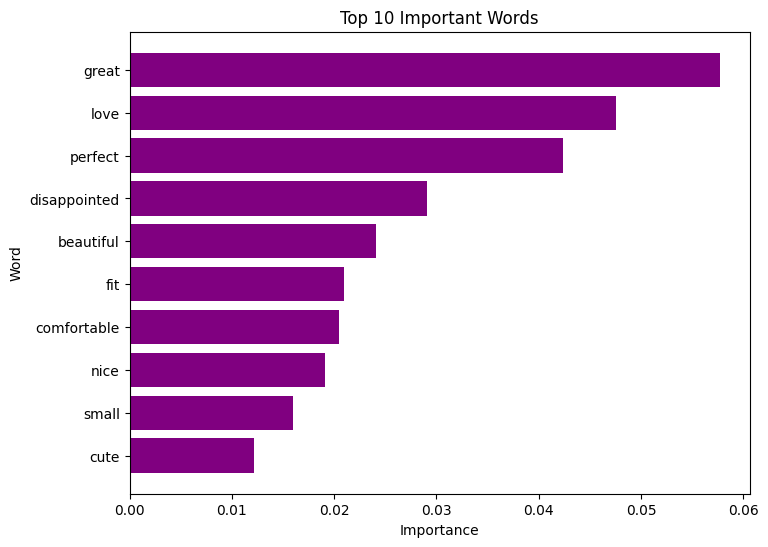

In [ ]:
# ============================================================
# STEP 65: TOP 10 FEATURE IMPORTANCE VISUALIZATION
# ============================================================

top10 = importance.head(10)

plt.figure(figsize=(8,6))

plt.barh(
    top10["Feature"],
    top10["Importance"],
    color="purple"
)

plt.title("Top 10 Important Words")
plt.xlabel("Importance")
plt.ylabel("Word")

plt.gca().invert_yaxis()

plt.show()

## **Feature Interpretation:**

In [ ]:
# The most important words are those that contribute the
# most to distinguishing positive and negative reviews.

# These words help explain the factors that influence
# customer satisfaction and dissatisfaction.